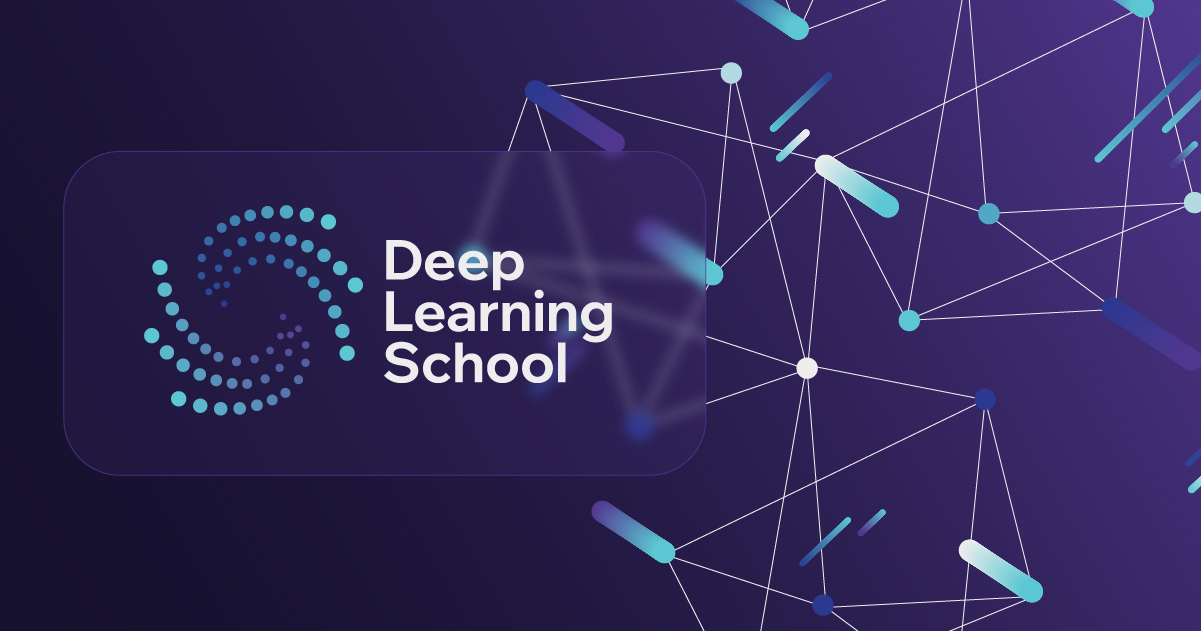

<h3 style="text-align: center;"><b>"Глубокое обучение". Продвинутый поток</b></h3>

<h2 style="text-align: center;"><b>Семинар. PyTorch. Батчнорм и дропаут. </b></h2>


In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import random
import numpy as np
import torch
import torch.nn.functional as F

from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm.notebook import tqdm

sns.set(font_scale=1.4, style="whitegrid")

In [2]:
# Зафиксируем сиды для воспроизводимости
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

In [3]:
# Выберем cuda или cpu
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
device

device(type='cuda')

# Загрузка датасета

[CIFAR-10](https://www.cs.toronto.edu/~kriz/cifar.html) — это набор данных, состоящий из 60 000 цветных изображений размером $32 \times 32$ пикселя, разделённых на 10 классов (например, самолёты, автомобили, птицы, кошки и др.). Из них 50 000 изображений используются для обучения моделей, а 10 000 — для их тестирования. Этот датасет широко применяется в задачах компьютерного зрения и отлично подходит для экспериментов с PyTorch.


In [4]:
classes = ("plane", "car", "bird", "cat",
           "deer", "dog", "frog", "horse", "ship", "truck")

def get_dataloaders(batch_size):
    transform = transforms.Compose(
        [transforms.ToTensor(),
         transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

    trainset = datasets.CIFAR10(root="./data", train=True,
                                            download=True, transform=transform)
    trainloader = DataLoader(trainset, batch_size=batch_size,
                                              shuffle=True, num_workers=2)
    testset = datasets.CIFAR10(root="./data", train=False,
                                           download=True, transform=transform)
    testloader = DataLoader(testset, batch_size=batch_size,
                                             shuffle=False, num_workers=2)
    return trainloader, testloader

В PyTorch датасетом считается любой объект, для которого определены методы `__len__(self)` и `__getitem__(self, i)`.

In [5]:
t, _ = get_dataloaders(1)

next(iter(t))[0].shape

100%|██████████| 170M/170M [00:03<00:00, 49.8MB/s]


torch.Size([1, 3, 32, 32])

# Код обучения

In [6]:
def train_one_epoch(model, loss_func, optimizer, train_dl):
    """
    Train the model for one epoch.

    Args:
        model (torch.nn.Module): Model to be trained.
        loss_func (callable): Loss function.
        optimizer (torch.optim.Optimizer): Optimization algorithm.
        train_dl (DataLoader): Dataloader for the training set.

    Returns:
        float: Average training loss over the entire epoch.
    """
    model.train()  # Set model to training mode
    total_loss = 0.0
    flag = True
    for xb, yb in tqdm(train_dl, desc="Training"):

        # Move data to the appropriate device
        xb, yb = xb.to(device), yb.to(device)

        # Forward pass
        preds = model(xb)
        if flag:
          print(preds)
          print(preds.shape)
          flag = False
        loss = loss_func(preds, yb)

        # Accumulate loss
        total_loss += loss.item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    # Return the average loss
    return total_loss / len(train_dl)


def validate(model, loss_func, valid_dl):
    """
    Validate the model on a given validation set.

    Args:
        model (torch.nn.Module): Model to be validated.
        loss_func (callable): Loss function.
        valid_dl (DataLoader): Dataloader for the validation set.

    Returns:
        float: Average validation loss over the entire validation set.
        float: Accuracy of the model on the validation set (0 to 1).
    """
    model.eval()  # Set model to evaluation mode
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    # for validation we don't need calculate gradients
    # ! eval() mode doen't turn off gradients !
    with torch.no_grad():
        for xb, yb in tqdm(valid_dl, desc="Validation"):
            # Move data to the appropriate device
            xb, yb = xb.to(device), yb.to(device)

            # Forward pass
            preds = model(xb)
            loss = loss_func(preds, yb)
            total_loss += loss.item()

            # Compute accuracy
            _, predicted_labels = torch.max(preds, dim=-1)
            total_correct += (predicted_labels == yb).sum().item()
            total_samples += xb.size(0)

    avg_loss = total_loss / len(valid_dl)
    accuracy = total_correct / total_samples
    return avg_loss, accuracy


def fit(epochs, model, loss_func, optimizer, train_dl, valid_dl):
    """
    Train and validate a model over a specified number of epochs.

    Args:
        epochs (int): Number of epochs to train.
        model (torch.nn.Module): Model to be trained and validated.
        loss_func (callable): Loss function (e.g., nn.CrossEntropyLoss()).
        optimizer (torch.optim.Optimizer): Optimization algorithm (e.g., SGD).
        train_dl (DataLoader): Dataloader for the training set.
        valid_dl (DataLoader): Dataloader for the validation set.

    Returns:
        tuple:
            - train_losses (list of float): Average training losses per epoch.
            - val_losses (list of float): Average validation losses per epoch.
            - valid_accuracies (list of float): Validation accuracies per epoch.
    """
    train_losses = []
    val_losses = []
    valid_accuracies = []

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # Train for one epoch
        train_loss = train_one_epoch(model, loss_func, optimizer, train_dl)

        # Validate after the epoch
        val_loss, val_acc = validate(model, loss_func, valid_dl)

        # Store metrics
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        valid_accuracies.append(val_acc)

        # Print a summary for quick reference
        print(f"Epoch {epoch+1} -> "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.4f}")

    return train_losses, val_losses, valid_accuracies

In [7]:
def plot_training(train_losses, valid_losses, valid_accuracies):
    """
    Plots training and validation losses, and validation accuracy over epochs.
    """
    plt.figure(figsize=(12, 9))

    # Plot training and validation losses in the first subplot
    plt.subplot(2, 1, 1)
    plt.xlabel("epoch")
    plt.plot(train_losses, label="train_loss")
    plt.plot(valid_losses, label="valid_loss")
    plt.legend()

    # Plot validation accuracy in the second subplot
    plt.subplot(2, 1, 2)
    plt.xlabel("epoch")
    plt.plot(valid_accuracies, label="valid accuracy")
    plt.legend()

In [8]:
class Model(nn.Module):
    def __init__(self):
        super(Model, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [9]:
model = Model()
model

Model(
  (conv1): Conv2d(3, 6, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(3, 3), stride=(1, 1))
  (fc1): Linear(in_features=576, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

Далее мы запускаем обучение модели:
- Определяем функцию потерь ([CrossEntropyLoss](https://colab.research.google.com/drive/1EOlgKwXSj9z7JqBl9sz2Xg-pfv2Xjw7e#scrollTo=RQygJ0ZHCgCK&line=2&uniqifier=1)) и оптимизатор ([SGD](https://pytorch.org/docs/stable/generated/torch.optim.SGD.html) с параметрами $\text{lr}=0.001$ и $\text{momentum}=0.9$).
- Запускаем обучение модели на $10$ эпох с помощью функции `fit` и визуализируем результаты (графики потерь и точности) с помощью plot_training.


Epoch 1/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[ 0.0707, -0.0117,  0.0663,  0.1372, -0.0950,  0.0422,  0.0487, -0.0581,
         -0.0925, -0.0830],
        [ 0.0616, -0.0189,  0.0651,  0.1324, -0.0812,  0.0493,  0.0522, -0.0684,
         -0.1068, -0.0832],
        [ 0.0612, -0.0211,  0.0580,  0.1261, -0.0939,  0.0477,  0.0266, -0.0734,
         -0.1065, -0.0812],
        [ 0.0618, -0.0184,  0.0723,  0.1648, -0.0831,  0.0479,  0.0336, -0.0599,
         -0.0968, -0.0861],
        [ 0.0762, -0.0107,  0.0719,  0.1349, -0.0906,  0.0591,  0.0509, -0.0701,
         -0.1050, -0.0696],
        [ 0.0515, -0.0274,  0.0588,  0.1418, -0.0857,  0.0566,  0.0319, -0.0497,
         -0.0972, -0.0668],
        [ 0.0846, -0.0296,  0.0550,  0.1276, -0.0939,  0.0419,  0.0369, -0.0489,
         -0.1043, -0.0760],
        [ 0.0522, -0.0212,  0.0511,  0.1222, -0.0993,  0.0404,  0.0195, -0.0711,
         -0.1085, -0.0854],
        [ 0.0788, -0.0240,  0.0684,  0.1498, -0.0903,  0.0425,  0.0304, -0.0315,
         -0.0957, -0.0810],
        [ 0.0742, -

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 2.0425 | Val Loss: 1.7857 | Val Acc: 0.3550

Epoch 2/10


...

Epoch 9 -> Train Loss: 0.9159 | Val Loss: 1.0138 | Val Acc: 0.6492

Epoch 10/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[ 0.3728, -3.5130, -0.2896,  4.0962, -0.0710,  1.8842,  2.7971, -2.1354,
         -0.7240, -1.9254],
        [ 0.6597, -3.3817,  1.4106,  1.3961,  1.6850,  1.2209, -0.5283,  1.0439,
         -1.7173, -1.6064],
        [ 0.1709, -1.6968,  1.0787,  3.8605, -2.3531,  3.7583,  0.6902, -0.2272,
         -4.4377, -1.0187],
        [-2.5186, -3.6704,  1.0364,  0.3177,  3.2309,  2.1192, -3.5566,  5.5035,
         -4.5120,  1.6304],
        [-0.7246,  1.5630, -1.4887, -1.0969, -1.5840, -1.0719, -1.1561,  0.8710,
         -2.0608,  4.6711],
        [-0.5799, -2.1102, -0.7644,  0.9246,  0.7100, -0.3781, -3.4981,  4.5197,
         -4.0826,  3.2168],
        [-0.6990, -3.5073,  1.8534,  2.0189,  0.5688,  2.5408,  0.2754, -0.9369,
         -0.3603, -0.7121],
        [-0.2141,  1.8500,  1.2603,  1.7288, -1.7727, -0.5862,  0.2321, -2.6551,
          0.3416,  0.9719],
        [-2.8621, -2.2630,  0.7889,  4.3978, -0.9427,  2.5062,  3.4331, -1.7125,
         -0.8479, -2.3693],
        [-0.9133, -

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 0.8703 | Val Loss: 1.0206 | Val Acc: 0.6431


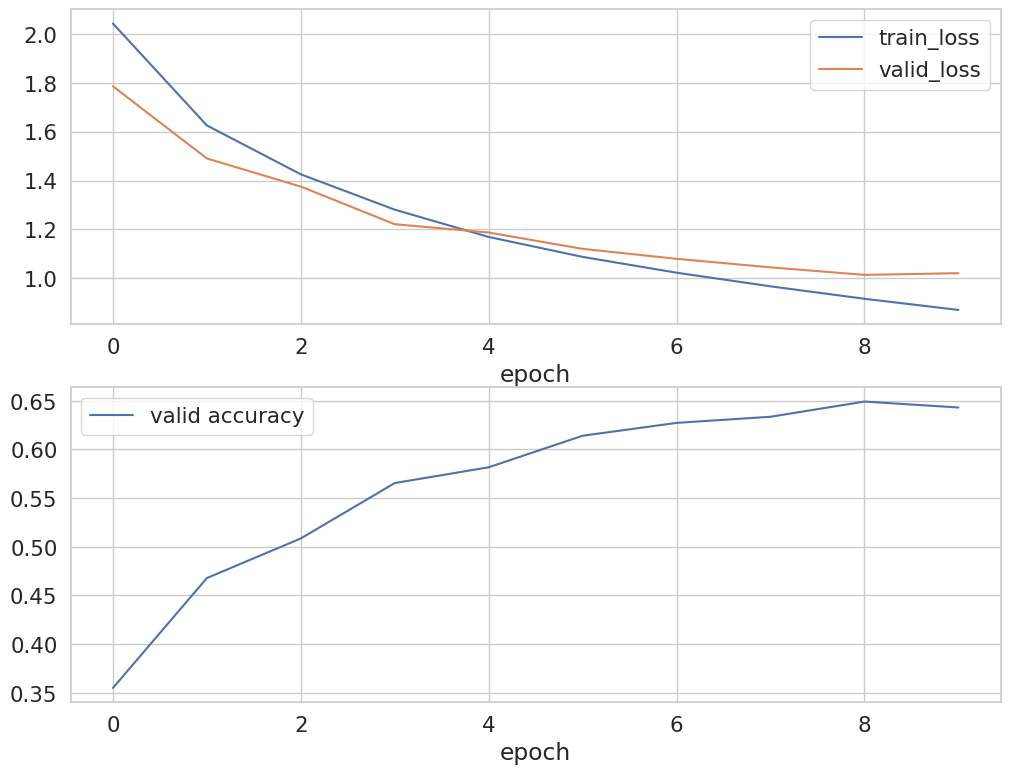

In [10]:
model = Model().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

info = fit(10, model, criterion, optimizer, *get_dataloaders(16))
plot_training(*info)

# BatchNorm
Ранее мы обсуждали, что для линейных моделей очень важно нормировать признаки перед подачей на вход. Когда мы работаем с нейронными сетями мы тоже нормируем вход, но есть ли какой-то способ нормировать признаки на внутренних слоях нейроной сети?

Да, существует несколько метдов нормировки признаков (BatchNorm, LayerNorm, InstanceNorm, etc). Научимся применять BatchNorm.


### BatchNorm, математика

<img src="https://production-media.paperswithcode.com/methods/batchnorm.png">

Если коротко, то `BatchNorm` для каждого признака вычитает среднее значение по батчу и делит на стандартное отклонение по батчу, потом домножает все признаки на вес $\gamma$ и прибавляет вес $\beta$. При этом возникает вопрос, что если мы используем модель уже для предсказаний и можем запускать ее только на одном примере.

`BatchNorm` работает по разному во время обучения и предсказний:


**Во время обучения**. Пусть батч состоит из $\mathbf{x_i}$ (каждый $\mathbf{x_i}$ - вектор, подающийся на вход). Тогда
$$\begin{aligned}
\mu_{\mathcal{B}} & \leftarrow \frac{1}{m} \sum_{i=1}^{m} x_{i} \\
\sigma_{\mathcal{B}}^{2} & \leftarrow \frac{1}{m} \sum_{i=1}^{m}\left(x_{i}-\mu_{\mathcal{B}}\right)^{2} \\
\widehat{x}_{i} & \leftarrow \frac{x_{i}-\mu_{\mathcal{B}}}{\sqrt{\sigma_{\mathcal{B}}^{2}+\epsilon}} \\
y_{i} & \leftarrow \gamma \widehat{x}_{i}+\beta \equiv \mathrm{B} \mathrm{N}_{\gamma, \beta}\left(x_{i}\right)
\end{aligned}$$

**Во время предсказания**. Мы делаем то же самое, но у нас нет батча. Поэтому в качестве $\mu_{\mathcal{B}}$ и $\sigma_{\mathcal{B}}$ мы используем среднее и стандартное отклонение признака во всем датасете. Обычно нам не хочется после обучения еще раз применять сеть ко всем примерам из обучающего датасета, чтобы вычислить эти статистики и мы вместо них используем экспоненциально затухающее среднее последних батчей.

### BatchNorm, что он дает?

* Более быстрое обучение. Болшие learning_rate"ы.
* Обучение более глубоких сетей.
* Регуляризация.
* Повышение точности моделей.

### BatchNorm для Conv слоев

Для сверточных слоев мы хотим следующее свойство **"если в разных частях картинки находятся одинаковые наборы пикселей, то соответствующие выходы сверточного слоя будут одинаковыми"**. Если бы мы применяли алгоритм, который описан выше, то получилось бы так, что для пикселей, находящихся в $1$ канале в координате $(1,1)$ среднее и стд могли бы получиться не такими же как для пикселя в $1$ канале в координате $(10, 10)$. Тогда даже если изначально в них были одинаковые значения, то после BatchNorm они стали бы разными.

Есть простое решение проблемы. Мы будем усреднять не только по `batch_size` координате, но и `height`, `width` координатам. Чтобы лучше объяснить используем псевдокод (origin https://stackoverflow.com/questions/38553927/batch-normalization-in-convolutional-neural-network):

На вход подается тензор (многомерный массив) размера $[B, H, W, C]$. Где $B$ -- количество батчей, $H$ -- высота картинок, $W$ -- ширина картинок, а C - количество каналов. Тогда обычный батчнорм выполнял бы нормирование так:
```python
# t is the incoming tensor of shape [B, H, W, C]
# mean and stddev are computed along 0 axis and have shape [H, W, C]
mean = mean(t, axis=0)
stddev = stddev(t, axis=0)
for i in 0..B-1:
  out[i,:,:,:] = norm(t[i,:,:,:], mean, stddev)
```

В то время как батчнорм для сверточных сетей (BatchNorm2D в PyTorch):

```python
# t is still the incoming tensor of shape [B, H, W, C]
# but mean and stddev are computed along (0, 1, 2) axes and have just [C] shape
mean = mean(t, axis=(0, 1, 2))
stddev = stddev(t, axis=(0, 1, 2))
for i in 0..B-1, x in 0..H-1, y in 0..W-1:
  out[i,x,y,:] = norm(t[i,x,y,:], mean, stddev)
```

### BatchNorm, порядок применения

В оригинальной статье (http://static.googleusercontent.com/media/research.google.com/en//pubs/archive/43442.pdf) для сверточных слоев батчнорм предлагают использовать сразу после свертки до активации. Я не смог найти статей, которые бы исследовали, нужно ли делать BN до или после активации, и, похоже, однозначного мнения нет + в более сложных архитектурах (ResNet"ы) исследователи обычно экспериментируют и ставят BN в разные места.

### BatchNorm, PyTorch

In [11]:
class ModelBatchNorm(nn.Module):
    def __init__(self):
        super(ModelBatchNorm, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.bn1 = nn.BatchNorm2d(6)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.bn2 = nn.BatchNorm2d(16)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.bn3 = nn.BatchNorm1d(120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.bn1(F.max_pool2d(F.relu(self.conv1(x)), (2, 2)))
        x = self.bn2(F.max_pool2d(F.relu(self.conv2(x)), 2))
        x = x.view(x.shape[0], -1)
        x = self.bn3(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [12]:
x = torch.rand((5,16,6,6))

x.view(x.shape[0], -1).shape

torch.Size([5, 576])


Epoch 1/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[ 0.1598,  0.1131, -0.1872, -0.1867, -0.1957,  0.0366,  0.2299, -0.4101,
         -0.1725, -0.2419],
        [-0.1757,  0.2008, -0.3551, -0.2706,  0.1327,  0.1899,  0.4731, -0.2658,
         -0.1803, -0.4769],
        [ 0.0336,  0.3172, -0.2158, -0.3935, -0.1946,  0.1944,  0.0505, -0.0469,
          0.1918, -0.2365],
        [-0.2136,  0.2647, -0.0670, -0.2404,  0.0323,  0.0055,  0.2427, -0.1234,
         -0.1858,  0.0174],
        [-0.6813, -0.0363, -0.7665, -0.2345,  0.0526,  0.4316,  0.4623, -0.2278,
         -0.4710, -0.7761],
        [-0.1282,  0.3931, -0.2329, -0.2782, -0.0884,  0.1243,  0.4971,  0.1669,
         -0.2065, -0.1893],
        [-0.3924,  0.2178,  0.2706, -0.2722,  0.2959,  0.4355, -0.0424,  0.1074,
          0.1083, -0.3614],
        [-0.1346,  0.5715, -0.1208, -0.2687, -0.2622, -0.0657, -0.1280, -0.3013,
          0.0018, -0.0157],
        [-0.1439,  0.3284, -0.1946, -0.2944, -0.2687,  0.0529,  0.2743, -0.4032,
          0.1425,  0.0920],
        [-0.5402,  

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 1.5626 | Val Loss: 1.2870 | Val Acc: 0.5320

Epoch 2/10


...

Epoch 9 -> Train Loss: 0.8459 | Val Loss: 0.9612 | Val Acc: 0.6618

Epoch 10/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[-1.3259,  1.7114,  2.8406,  0.0799, -1.9478, -0.7120, -1.6177, -1.2261,
         -0.7716,  3.9522],
        [-2.7551, -3.1472, -1.1574,  5.0503,  2.1959,  2.3110,  2.8141, -0.7384,
         -3.3576, -3.6593],
        [ 0.8865, -2.9192,  2.8013,  0.9305,  3.1626, -1.6641,  2.1012, -0.7889,
         -3.0205, -3.1414],
        [ 1.5089,  3.2268, -1.6457, -2.1748, -1.1050, -2.1250, -1.5705, -1.2385,
         -0.0944,  5.2236],
        [ 1.9680,  4.6199, -1.4709, -2.3083, -0.4258, -3.1843, -1.4589, -1.5159,
          0.6867,  0.2404],
        [ 0.3814, -2.6702,  2.7244,  0.7145, -0.2233,  0.5905,  2.3652, -2.3632,
         -0.4049, -2.2353],
        [-0.8836, -3.5072, -0.7881,  2.1262,  0.3114,  2.1027,  1.4877, -1.1391,
          1.8688, -3.9190],
        [-2.2215, -0.8367,  0.0681,  1.2189, -0.5325,  1.3910,  3.1274, -1.4922,
         -2.0576, -1.0438],
        [ 1.1436, -0.8764,  3.3539, -1.8857,  5.1995, -1.0667, -1.7944,  2.0672,
         -4.3457, -2.5819],
        [ 1.3233, -

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 0.8079 | Val Loss: 0.9654 | Val Acc: 0.6679


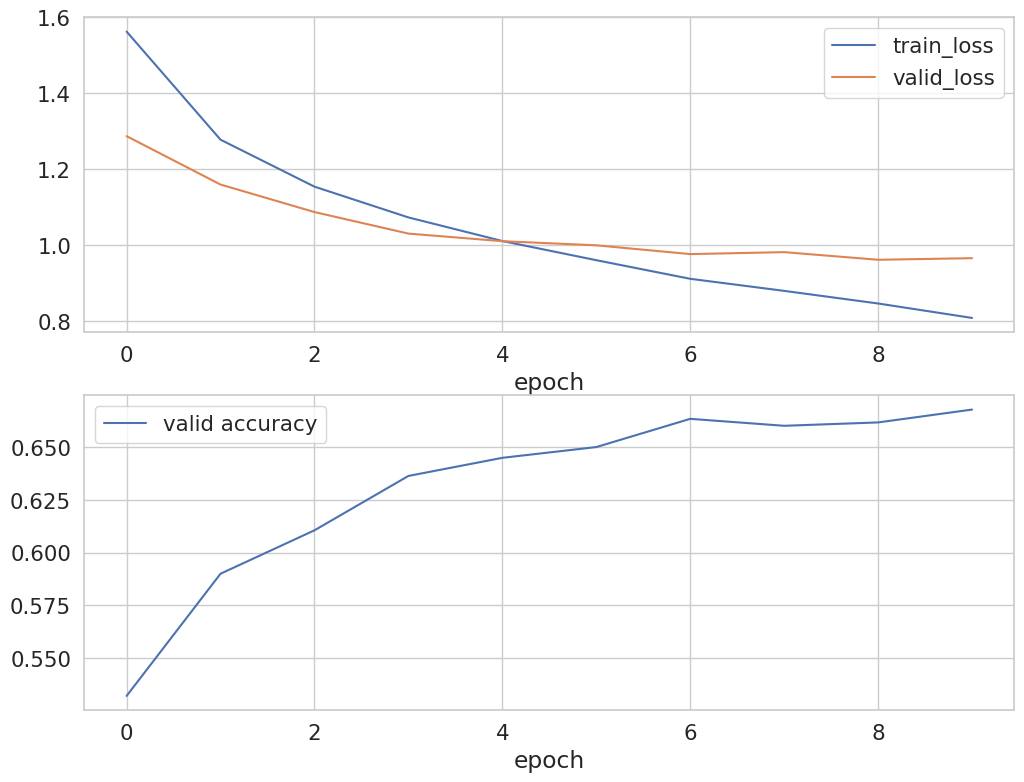

In [13]:
model = ModelBatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

info = fit(10, model, criterion, optimizer, *get_dataloaders(16))
plot_training(*info)

Вспомните как выглядели формулы для BatchNorm: если размер батча равен $1$, то $\sigma = 0$, и у нас есть деление на ноль. PyTorch **не умеет обрабатывать такой случай и падает**:

In [14]:
model = ModelBatchNorm().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)

fit(1, model, criterion, optimizer, *get_dataloaders(batch_size=1))


Epoch 1/1


Training:   0%|          | 0/50000 [00:00<?, ?it/s]

ValueError: Expected more than 1 value per channel when training, got input size torch.Size([1, 120])

# Dropout

<img src="https://wenkangwei.github.io/images/DL/dropout.jpg" width="1200" height="350">


Дропаут это еще один необычный слой, который используется в нейронных сетях. У него есть один гиперпараметр $p$.

Идея дропаута состоит в том, что во время обучения мы зануляем случайную часть входа и отдаем вход дальше (для каждого числа мы подбрасываем монетку и с вероятностью $p$ зануляем это число).

Дропаут позволяет тренировать более устойчивые сети и избегать переобучения.

### Dropout, механика работы.

Как мы сказали выше, dropout зануляет случайную часть входов и отдает их дальше. Допустим $p=0.5$ (достаточное популярное значение). Тогда мы просто убираем половину всего входа! Такое сильное воздействие явно плохо повлияет на качество нашей модели, поэтому мы делаем зануление только во время обучения.

**Во время обучения**: для каждого числа во входе подбрасываем монетку и зануляем его с вероятностью $p$. Выход умножаем на $\frac{1}{1-p}$, чтобы дисперсия выходов осталось такой же, как и на входе.

**Во время предсказаний**: ничего не делаем).

### Dropout, что дает?

* Сеть выучивает более устойчивые представления на внутренних слоях.
* Сильно увеличивает число итераций, которые нужны для сходимости.
* Можно получить интерпретацию, которая говорит, что дропаут усредняет выходы большо числа нейросетей с $p|W|$ нейронами на предыдущем слоев.

Дропаут вызывает интересный эффект: в начале обучения качество на тестовом датасете выше, чем на обучающем. Потому что для обучающего датасета у нас есть зануление, которое сильно портит предсказания.

### Dropout, взаимодействие с BatchNorm.

Статья, исследующая, почему исопльзование дропаута и батчнорма вместе часто ведет к более плохим результатам, чем их использование по-отдельности - https://arxiv.org/pdf/1801.05134.pdf

Картинка из статьи, объясняющая проблему:
![img](https://media.arxiv-vanity.com/render-output/3934414/x1.png)

(Если совсем коротко, то при наличии дропаута во время обучения и во время предсказаний выходы дропаута имеют разное распределение. Поэтому статистики, которые batchnorm считает для применения во время предсказаний, оказываются неверными.)

Решение: если вы хотите использовать батчнорм и дропаут в одной сети, то все Dropout"ы должны идти после BatchNorm"ов.

### Dropout, PyTorch

В PyTorch есть `F.dropout(x, p=p)` и слой `nn.Dropout(p=p)`. В чем их отличие? `F.dropout(x, p=p)` не будет изменять свое поведение в заивимости от того, в каком стостянии сейчас модель (train, eval).

Теперь чуть подробнее:

Когда вы вызываете model.train()/model.eval() PyTorch проходится по всем переменным класса и если видит там наследника nn.Module или nn.ModuleList, то также меняет состояние для всех найденных модулей. Т.е. версия со слоем будет автоматически работать с train/eval состяниями.

In [15]:
class ModelDropout(nn.Module):
    def __init__(self):
        super(ModelDropout, self).__init__()
        # 1 input image channel, 6 output channels, 3x3 square conv kernel
        self.conv1 = nn.Conv2d(3, 6, 3)
        self.conv2 = nn.Conv2d(6, 16, 3)
        self.fc1 = nn.Linear(16 * 6 * 6, 120)  # 5x5 image dimension
        self.dropout = nn.Dropout(p=0.3)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(x.shape[0], -1)
        x = self.dropout(F.relu(self.fc1(x)))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


Epoch 1/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[-8.2401e-02, -7.4804e-02,  6.3815e-02, -2.5877e-02,  9.9551e-03,
         -6.5258e-02,  9.6595e-02,  5.9067e-02, -4.1284e-02,  1.1506e-02],
        [-7.4966e-02, -7.1989e-02,  6.3288e-02, -2.0860e-02,  6.9899e-03,
         -6.2202e-02,  1.1162e-01,  6.2692e-02, -5.0927e-02, -9.9686e-03],
        [-7.5798e-02, -5.6215e-02,  4.7770e-02, -1.6646e-02,  2.8983e-02,
         -5.2379e-02,  8.3463e-02,  6.3260e-02, -4.9799e-02,  8.1075e-03],
        [-8.7378e-02, -6.3030e-02,  6.4911e-02, -2.5825e-02,  1.9570e-02,
         -5.0745e-02,  1.0228e-01,  6.7602e-02, -5.1457e-02,  7.6678e-05],
        [-7.1508e-02, -7.2122e-02,  5.7598e-02, -2.0463e-02,  1.9230e-02,
         -4.9845e-02,  1.0191e-01,  6.5665e-02, -5.4933e-02, -2.3549e-03],
        [-6.7264e-02, -6.6809e-02,  5.6684e-02, -1.2661e-02,  3.1125e-02,
         -3.5509e-02,  9.8586e-02,  8.1194e-02, -5.7070e-02,  1.2894e-03],
        [-7.8265e-02, -7.4347e-02,  6.2070e-02, -2.0323e-02,  1.4483e-02,
         -5.6615e-02,  1.1002e-0

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 1 -> Train Loss: 1.6705 | Val Loss: 1.4169 | Val Acc: 0.4854

Epoch 2/10


...

Epoch 9 -> Train Loss: 1.1245 | Val Loss: 1.1362 | Val Acc: 0.6113

Epoch 10/10


Training:   0%|          | 0/3125 [00:00<?, ?it/s]

tensor([[-0.3796, -4.3156,  2.7002,  2.0123, -2.2668,  5.7391, -1.8406,  2.1002,
         -0.9645, -2.5267],
        [-0.6553, -6.0380,  3.1706,  1.9455, -0.6899,  5.7710, -3.6129,  2.4222,
         -0.2838, -3.5407],
        [-0.1409, -2.6289,  1.0233,  1.2884,  0.8452,  1.3297, -1.3699,  0.1680,
         -0.4637, -1.2342],
        [ 5.3759,  2.1927,  5.4782,  2.3707, -0.6599, -0.6493, -2.8205, -3.5458,
         -3.0616,  1.5306],
        [ 0.3303,  4.8873,  0.3236, -0.1889, -2.1570, -2.1011, -1.6760, -1.9358,
         -1.1782,  3.0679],
        [ 6.0579, -1.0908,  1.2211, -3.8637,  4.0026, -3.7643, -6.6716,  0.5430,
          1.7425,  0.6188],
        [-3.7087, -2.5862,  2.0551,  4.8416,  2.0520, -0.8007,  8.9529, -2.8848,
         -4.3188, -5.3997],
        [ 0.5423, -0.1381,  0.4099, -0.4158, -0.6077, -0.2144, -3.0870,  2.5145,
         -1.3659,  2.8717],
        [-1.0732, -3.6080,  2.7755,  1.6225,  1.1339,  2.6879,  0.4526,  2.0453,
         -1.9034, -3.0798],
        [ 4.1018,  

Validation:   0%|          | 0/625 [00:00<?, ?it/s]

Epoch 10 -> Train Loss: 1.1213 | Val Loss: 1.1727 | Val Acc: 0.6019


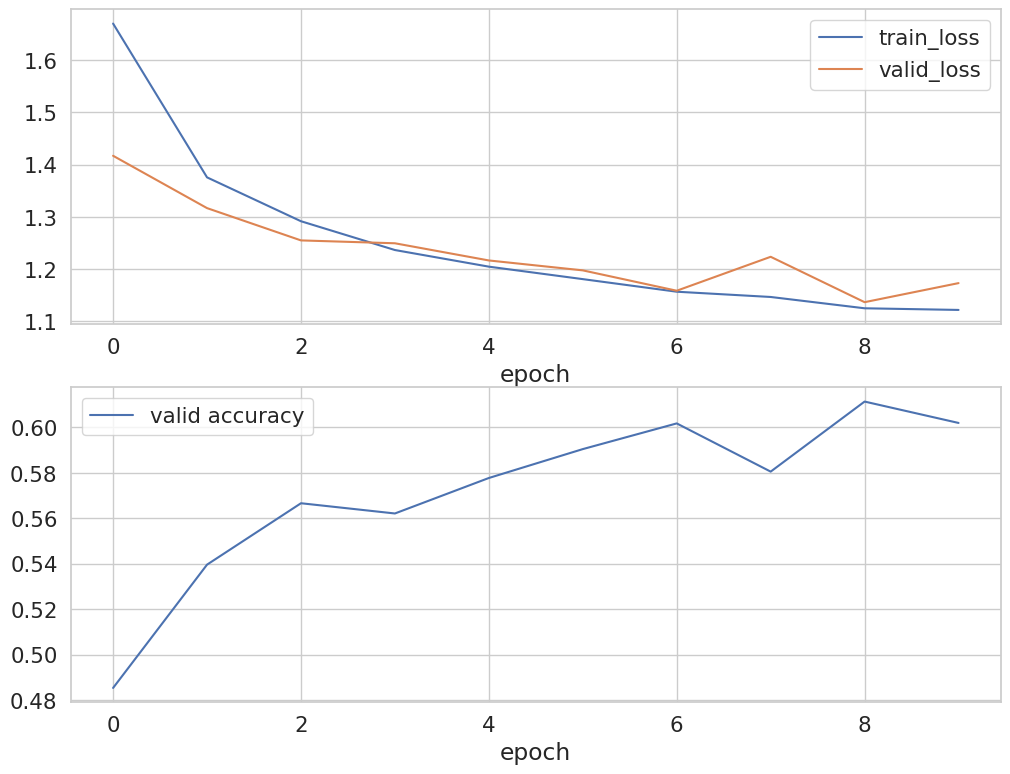

In [17]:
model = ModelDropout().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
scheduler = optim.lr_scheduler.ExponentialLR(optimizer=optimizer, gamma=0.5)

info = fit(10, model, criterion, optimizer, *get_dataloaders(16))
plot_training(*info)